# **Midterm Exam Take Home (Modeling Portion)**
**Name:** Christine Wu
**Date:** 05/07/2026

## **0. Data Importing**

In [2]:
# Load the training data file
import pandas as pd
train = pd.read_csv(r"/Users/christinewu/Desktop/academic resources/Advanced Machine Learning/Midterm Files/midterm_train.csv")
train.head()

,id,customer_age,occupation_type,relationship_status,education_background,has_credit_issue,mortgage_status,personal_loan_status,last_contact_month,day_of_week,...,prior_contact_count,prior_outcome_status,economic_activity_change,consumer_price_index,consumer_confidence_index,reference_interest_rate,employment_level_index,accepted_offer,is_repeat_customer,recent_contact_flag
0,12556,28,services,married,high.school,no,yes,no,jul,tue,...,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,0,0,0
1,35451,27,admin.,married,university.degree,no,yes,yes,jul,fri,...,0,nonexistent,1.4,93.918,-42.7,4.959,5228.1,0,0,0
2,30592,43,self-employed,married,high.school,unknown,yes,no,apr,wed,...,0,nonexistent,-1.8,93.075,-47.1,1.498,5099.1,0,0,0
3,17914,43,admin.,single,university.degree,no,yes,no,aug,fri,...,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0,0,0
4,3315,41,admin.,married,unknown,no,no,no,sep,wed,...,3,success,-1.1,94.199,-37.5,0.886,4963.6,1,1,1


## **1. Exploratory Data Analysis**
Include a small number of relevant summaries or plots and focus on insights that influenced your modeling.

### **a. SweetViz EDA**

To understand the structure, distributions, and relationships within the dataset, we begin with an automated EDA report using the SweetViz library. 

SweetViz provides a comprehensive overview of:
- Feature distributions
- Missing values
- Relationships with the target variable (`accepted_offer`)
- Potential data quality issues

This helps quickly identify patterns and guides more focused analysis.

In [3]:
# Install SweetViz if not already installed
#!pip install sweetviz

import sweetviz as sv

# Generate SweetViz report
eda_report = sv.analyze(train, target_feat='accepted_offer')

# Display the report in the notebook (or save as HTML)
eda_report.show_html("sweetviz_eda_report.html")

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)

Report sweetviz_eda_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


#### **Key Findings from SweetViz EDA**

The SweetViz EDA report provides a high-level overview of the dataset, which consists of 23 features, including 14 categorical and 9 numerical variables.

#### 1. Feature Composition
The dataset is primarily composed of categorical variables, suggesting that customer behavior and segmentation (e.g., demographics, prior interactions, and status variables) will likely play a significant role in predicting whether an offer is accepted.

#### 2. Relationship Strength with Target
Overall, the direct associations between individual features and the target variable (`accepted_offer`) appear relatively weak. Most categorical associations with the target have low values (generally close to 0), indicating that:
- No single variable strongly predicts acceptance on its own
- The prediction problem likely requires combining multiple features
- More complex models (e.g., tree-based methods) may perform better than simple linear models

#### 3. Informative Features
Some variables show relatively stronger (though still modest) relationships with the target or with other features:
- `last_contact_month` shows some association with `accepted_offer` and other variables
- Behavioral variables such as:
  - `prior_contact_count`
  - `recent_contact_flag`
  - `prior_outcome_status`
  - `is_repeat_customer`
  may contain useful predictive signals.

These features capture customer engagement history, which is often important in marketing response prediction models.

#### 4. Feature Interactions
Several features exhibit stronger relationships with each other than with the target (e.g., `last_contact_month` and `economic_activity_change`).

This suggests:
- Potential multicollinearity
- Opportunities for interaction effects
- The need for models that can capture nonlinear relationships

#### 5. Modeling Implications
Based on the EDA:
- Feature engineering and interaction modeling will be important
- Tree-based models (e.g., Random Forest, Gradient Boosting) are likely appropriate
- Categorical encoding strategies (e.g., one-hot or target encoding) will be critical
- Simple models may underperform due to weak individual feature signals

### **b. Additional Visualizations that capture patterns in the data**

I have chosen to include 2-3 additional plots that clearly influence modeling decisions, which I have done on my own to further understand the data outside of just using SweetViz.

#### Plot 1: Target Distribution (Class Imbalance)

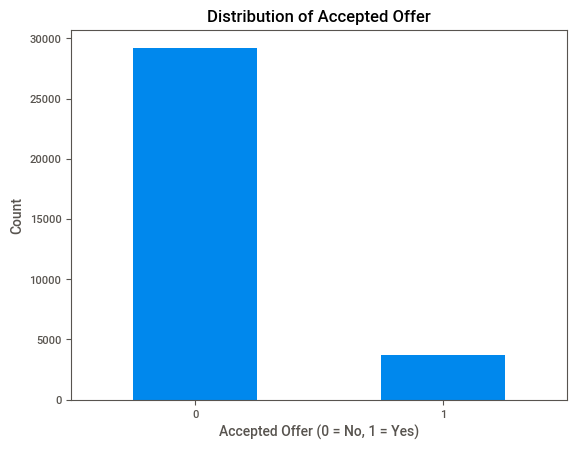

accepted_offer
0    0.887253
1    0.112747
Name: proportion, dtype: float64

In [4]:
import matplotlib.pyplot as plt

train['accepted_offer'].value_counts().plot(kind='bar')

plt.title("Distribution of Accepted Offer")
plt.xlabel("Accepted Offer (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.show()

train['accepted_offer'].value_counts(normalize=True)

**Insight**

The target variable (`accepted_offer`) is highly imbalanced, with a significantly larger proportion of customers not accepting the offer (0) compared to those who do (1).

This class imbalance has important implications for modeling:
- A naive model could achieve high accuracy by simply predicting the majority class (0), but would perform poorly in identifying actual acceptances
- Evaluation metrics such as accuracy alone may be misleading; metrics like precision, recall, F1-score, or ROC-AUC should be considered
- Techniques such as class weighting, resampling (e.g., oversampling the minority class), or threshold tuning may be necessary to improve performance

From a business perspective, correctly identifying customers who are likely to accept the offer is critical, making it especially important to address this imbalance during model development.


#### Plot 2: Prior Contact Behavior vs Target

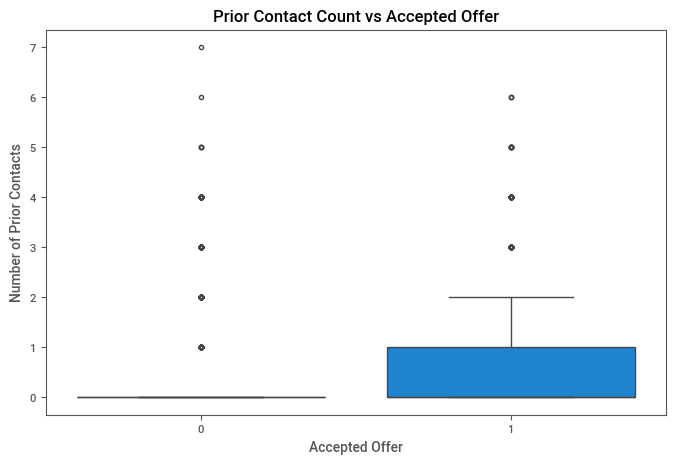

In [7]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(x='accepted_offer', y='prior_contact_count', data=train)

plt.title("Prior Contact Count vs Accepted Offer")
plt.xlabel("Accepted Offer")
plt.ylabel("Number of Prior Contacts")

plt.show()

**Insight**
The distribution of prior contact count differs noticeably between customers who accepted the offer and those who did not.

Customers who did not accept the offer (0) have a median of 0 prior contacts, with most observations concentrated at zero. Meanwhile, customers who accepted the offer (1) tend to have slightly higher prior contact counts, with a wider spread and more observations above zero.

This suggests that customers who have been contacted more frequently are more likely to accept the offer, indicating that prior engagement plays an important role in conversion.

However, the overall range remains relatively low, and there is still significant overlap between the two groups. This implies that while `prior_contact_count` is informative, it is not sufficient on its own and should be used in combination with other features in the model!

#### Plot 3: Categorical Feature (e.g., Previous Outcome)

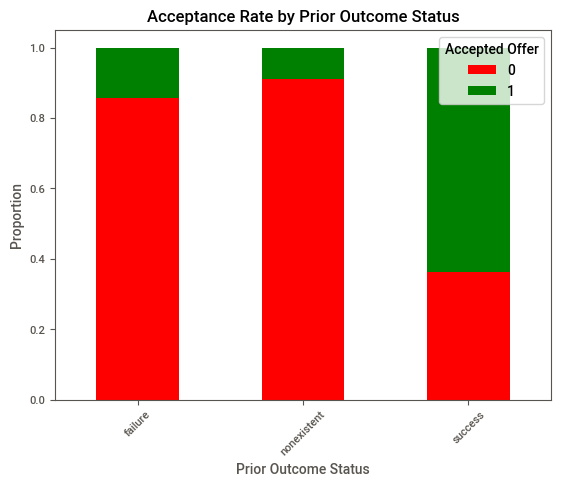

In [9]:
cross_tab = pd.crosstab(train['prior_outcome_status'], train['accepted_offer'], normalize='index')

cross_tab.plot(
    kind='bar',
    stacked=True,
    color=['red', 'green']
)

plt.title("Acceptance Rate by Prior Outcome Status")
plt.xlabel("Prior Outcome Status")
plt.ylabel("Proportion")
plt.legend(title="Accepted Offer")

plt.xticks(rotation=45)
plt.show()

**Insight**

Acceptance rates vary significantly across prior outcome categories, indicating that past campaign outcomes are a strong predictor of future behavior.

Customers with a prior outcome of "success" show a substantially higher acceptance rate, with the majority accepting the offer. In contrast, customers with "failure" or "nonexistent" prior outcomes have much lower acceptance rates, with most customers not accepting the offer.

This suggests that:
- Prior campaign success is a strong indicator of customer responsiveness.
- Historical interaction outcomes carry meaningful predictive signal.

From a modeling perspective, this feature is likely to be highly informative and should be prioritized. It may also be useful for segmentation, as customers with prior success represent a high-value target group for future campaigns.

#### **Workflow Touchpoint**

**EDA Summary & Next Steps**

Based on the SweetViz report and the additional visualizations, a few key themes stand out.

First, the target variable is clearly imbalanced, with far more customers not accepting the offer than accepting it. This means I need to be careful with model evaluation and likely incorporate techniques such as class weighting or resampling to avoid bias toward the majority class.

Second, no single feature appears to be overwhelmingly predictive on its own. However, several variables (especially those related to prior customer interactions (e.g., prior contact count, prior outcome status, and recent contact indicators)) show meaningful patterns. In particular, prior outcome status stands out as a strong predictor, suggesting that historical campaign success is highly informative.

Third, many relationships appear to be relatively weak individually but potentially useful when combined. This suggests that models capable of capturing nonlinearities and interactions (such as tree-based models) may perform better than simpler linear approaches.

**Next Steps: Data Preprocessing**

Based on these findings, my next steps will focus on preparing the data for modeling:

- Handling class imbalance: I will consider using class weights or resampling techniques to ensure the model properly learns the minority class (accepted offers).
- Encoding categorical variables: Since a large portion of the dataset is categorical, I will apply appropriate encoding methods (e.g., one-hot encoding or similar techniques).
- Feature selection / engineering: I will prioritize variables related to customer interaction history and consider creating interaction features if useful.
- Train-validation split: I will split the data into training and validation sets to properly evaluate model performance.
- Baseline model: I will start with a simple baseline model and then move toward more flexible models (e.g., tree-based methods) based on the patterns observed in the EDA.

Overall, the EDA suggests that this is not a simple prediction problem, and model performance will likely depend on combining multiple features and handling class imbalance carefully.

## **2. Data Preparation**
Show the preprocessing steps used for modeling.

**Note:** Before modeling, I need to prepare the dataset so it can be used by machine learning algorithms. Based on the EDA, the main preprocessing needs are:

- Separate the target variable (`accepted_offer`) from the predictors
- Remove the `id` column because it is an identifier, not a useful predictor
- Encode categorical variables so models can interpret them
- Scale numeric variables for consistency
- Split the data into training and validation sets
- Account for class imbalance using stratified splitting and class weighting where possible

Since I plan to use one bagging model and one boosting model, I will create a preprocessing pipeline that can be reused consistently across both models.

### 0. Import packages

In [10]:
# Core data preparation tools
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Models planned for the next section
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

# Evaluation tools for imbalanced classification
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

### 1. Seperate target and features.

In [12]:
# The target variable is what we want to predict
target = "accepted_offer"

# Drop the target from X and remove id since it is only an identifier
X = train.drop(columns=[target, "id"])
y = train[target]

# Quick check
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (32950, 21)
Target shape: (32950,)


### 2. Identify categorical and numeric columns

In [13]:
# Categorical variables need encoding before modeling
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

# Numeric variables can be scaled
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumeric features:")
print(numeric_features)

Categorical features:
['occupation_type', 'relationship_status', 'education_background', 'has_credit_issue', 'mortgage_status', 'personal_loan_status', 'last_contact_month', 'day_of_week', 'prior_outcome_status']

Numeric features:
['customer_age', 'contact_time_minutes', 'contact_attempt_count', 'days_since_prior_contact', 'prior_contact_count', 'economic_activity_change', 'consumer_price_index', 'consumer_confidence_index', 'reference_interest_rate', 'employment_level_index', 'is_repeat_customer', 'recent_contact_flag']


### 3. Create preprocessing transformer

In [14]:
# OneHotEncoder converts categorical columns into model-readable binary columns.
# handle_unknown="ignore" prevents errors if validation/test data has new categories.

# StandardScaler puts numeric variables on a similar scale.
# This is especially useful for models sensitive to scale, and it keeps preprocessing consistent.

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numeric", StandardScaler(), numeric_features)
    ]
)

### 4. Train-validation split

In [15]:
# Stratify keeps the accepted/not accepted proportion similar in both sets.
# This is important because the target variable is imbalanced.

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Validation set shape:", X_valid.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nValidation target distribution:")
print(y_valid.value_counts(normalize=True))

Training set shape: (26360, 21)
Validation set shape: (6590, 21)

Training target distribution:
accepted_offer
0    0.887253
1    0.112747
Name: proportion, dtype: float64

Validation target distribution:
accepted_offer
0    0.887253
1    0.112747
Name: proportion, dtype: float64


### 5. Create model pipelines using the same preprocessing

In [16]:
# Bagging model: Random Forest
# class_weight="balanced" helps account for class imbalance.
bagging_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        ))
    ]
)

# Boosting model: Histogram Gradient Boosting
# This model does not use class_weight directly in the same way,
# but it is still useful as a strong boosting baseline.
boosting_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", HistGradientBoostingClassifier(
            random_state=42
        ))
    ]
)

#### **Workflow Touchpoint**

At this point, the data has been cleaned, encoded, and split into training and validation sets, and I have established a consistent preprocessing pipeline that can be reused across models.

The next step is to improve model performance through feature engineering and feature selection.

Based on the EDA, I plan to focus on the following:

##### Feature Engineering

- Leverage customer interaction history: Variables such as `prior_contact_count`, `recent_contact_flag`, and `prior_outcome_status` showed meaningful patterns. I will consider creating derived features that better capture customer engagement (e.g., grouping contact frequency or combining interaction indicators).
- Capture nonlinear effects: Since relationships with the target are not strictly linear, I may transform or bucket numerical variables to better reflect patterns observed in the data.
- Explore interactions between variables: Some features showed stronger relationships with each other than with the target, suggesting that interaction terms may improve predictive power.

##### Feature Selection

- Prioritize informative features: Based on EDA, I expect variables related to prior outcomes and customer behavior to be more predictive and will evaluate their importance in the models.
- Use model-based importance: I will use feature importance from tree-based models (Random Forest and Boosting) to identify which features contribute most to prediction.
- Reduce noise and redundancy: If certain features provide little signal or are highly redundant, I will consider removing them to simplify the model and reduce overfitting.

Overall, the goal in the next section is to refine the feature set so that the models can better capture the patterns identified during EDA while avoiding unnecessary complexity.

## **3. Feature Engineering or Feature Selection**
Evaluate whether feature engineering or feature selection improved or simplified your model.

**Note:** In this section, I create a small set of targeted features based on the EDA findings. I am focusing mainly on customer interaction history, prior campaign outcomes, and nonlinear patterns that may help the bagging and boosting models capture stronger signal.

I am also preparing a feature selection process so that I can later compare whether the engineered features improved the model or helped simplify it.

### 0. Feature Engineering Setup
I will create engineered features on a copy of the original training data. This keeps the original dataset unchanged in case I need to compare results later.

In [17]:
# Feature Engineering Setup
train_fe = train.copy()

### 1. Prior Contact Indicator
**Reasoning:**
- The EDA showed that prior contact behavior is related to offer acceptance.
- This feature captures whether the customer had any prior contact at all.
- This is slightly different from prior_contact_count because it simplifies the idea of "any previous engagement" into a binary signal.

In [18]:
train_fe["had_prior_contact"] = np.where(
    train_fe["prior_contact_count"] > 0,
    1,
    0
)

### 2. Contact Frequency Group
**Reasoning:**
- Plot 2 showed that most customers had very few prior contacts, but customers who accepted the offer tended to have slightly higher prior contact counts.
- Instead of assuming the relationship is perfectly linear, I group contact count into buckets.
- This may help tree-based models capture nonlinear engagement patterns.

In [19]:
def contact_frequency_group(count):
    if count == 0:
        return "no_prior_contact"
    elif count == 1:
        return "one_prior_contact"
    elif count <= 3:
        return "two_to_three_contacts"
    else:
        return "four_plus_contacts"

train_fe["prior_contact_group"] = train_fe["prior_contact_count"].apply(contact_frequency_group)

### 3. Prior Success Indicator
**Reasoning:**
- The prior outcome plot showed that customers with a prior outcome of "success" had a much higher acceptance rate than customers with "failure" or "nonexistent". 
- This feature directly captures that strong signal in a simple binary form.

In [20]:
train_fe["had_prior_success"] = np.where(
    train_fe["prior_outcome_status"] == "success",
    1,
    0
)

### 4. Prior Failure Indicator
**Reasoning:**
- Customers with a prior outcome of "failure" had much lower acceptance rates
- Separating prior success and prior failure may help the model distinguish between positive prior engagement and unsuccessful prior engagement.

In [21]:
train_fe["had_prior_failure"] = np.where(
    train_fe["prior_outcome_status"] == "failure",
    1,
    0
)

### 5. Repeat Customer with Recent Contact
**Reasoning**
- `is_repeat_customer` and `recent_contact_flag` both describe customer interaction history.
- Combining them creates a feature for customers who are both repeat customers and were contacted recently, which may indicate stronger engagement.

In [22]:
train_fe["repeat_and_recent_contact"] = np.where(
    (train_fe["is_repeat_customer"] == 1) & (train_fe["recent_contact_flag"] == 1),
    1,
    0
)

### 6. High Current Campaign Contact Pressure
**Reasoning**
- `contact_attempt_count` measures how many times the customer was contacted in the current campaign.
- Very high contact attempts may reflect either persistence or customer resistance.
- I create a high-contact indicator using the 75th percentile as a data-driven cutoff.

In [28]:
contact_attempt_threshold = train_fe["contact_attempt_count"].quantile(0.75)

train_fe["high_contact_attempts"] = np.where(
    train_fe["contact_attempt_count"] > contact_attempt_threshold,
    1,
    0
)

print("75th percentile contact attempt threshold:", contact_attempt_threshold)

75th percentile contact attempt threshold: 3.0


### 7. Contact Time Group
**Reasoning:**
- contact_time_minutes may be predictive because longer calls can indicate stronger customer interest.
- However, the relationship may not be linear, so I create buckets based on quartiles.
- This lets the model capture short, medium, and long interactions more flexibly.

In [23]:
train_fe["contact_time_group"] = pd.qcut(
    train_fe["contact_time_minutes"],
    q=4,
    labels=["short", "medium_short", "medium_long", "long"],
    duplicates="drop"
)

### 8. Age Group
**Reasoning**
- Customer age may have a nonlinear relationship with offer acceptance.
- Grouping age can help capture broad customer life-stage segments without assuming that each additional year has the same effect.

In [24]:
train_fe["age_group"] = pd.cut(
    train_fe["customer_age"],
    bins=[0, 30, 45, 60, 100],
    labels=["under_30", "30_to_45", "46_to_60", "over_60"]
)

### 9. Days Since Prior Contact: No Previous Contact Flag

**Reasoning:**
- The data dictionary notes that `days_since_prior_contact` uses a special negative value when there was no earlier contact.
- This engineered feature explicitly marks those cases instead of forcing the model to interpret the negative value as a normal numeric value.

In [25]:
train_fe["no_previous_contact_flag"] = np.where(
    train_fe["days_since_prior_contact"] < 0,
    1,
    0
)

### 10. Cleaned Days Since Prior Contact
**Reasoning:**
- Since negative values represent "no earlier contact," they should not be treated as true negative time values.
- I replace negative values with 0 so the numeric feature better represents recency.


In [26]:
train_fe["days_since_prior_contact_clean"] = np.where(
    train_fe["days_since_prior_contact"] < 0,
    0,
    train_fe["days_since_prior_contact"]
)

### 11. Review Engineered Features

In [29]:
engineered_features = [
    "had_prior_contact",
    "prior_contact_group",
    "had_prior_success",
    "had_prior_failure",
    "repeat_and_recent_contact",
    "high_contact_attempts",
    "contact_time_group",
    "age_group",
    "no_previous_contact_flag",
    "days_since_prior_contact_clean"
]

train_fe[engineered_features].head()

,had_prior_contact,prior_contact_group,had_prior_success,had_prior_failure,repeat_and_recent_contact,high_contact_attempts,contact_time_group,age_group,no_previous_contact_flag,days_since_prior_contact_clean
0,0,no_prior_contact,0,0,0,0,medium_long,under_30,0,999
1,0,no_prior_contact,0,0,0,0,medium_short,under_30,0,999
2,0,no_prior_contact,0,0,0,0,long,30_to_45,0,999
3,0,no_prior_contact,0,0,0,0,medium_long,30_to_45,0,999
4,1,two_to_three_contacts,1,0,1,0,long,30_to_45,0,7


Based on the summary, I don't see any issues with the created features so I'll proceed to feature selection.

### 12. Feature Selection Preparation
**Reasoning:**
- I remove the original id column because it is only an identifier.
- I also remove the original `days_since_prior_contact` because I created a cleaner version and a separate `no_previous_contact_flag` to represent the special negative value.

In [30]:
target = "accepted_offer"

features_to_drop = [
    "id",
    target,
    "days_since_prior_contact"
]

X_fe = train_fe.drop(columns=features_to_drop)
y_fe = train_fe[target]

print("Feature matrix after engineering:", X_fe.shape)
print("Target shape:", y_fe.shape)

Feature matrix after engineering: (32950, 30)
Target shape: (32950,)


### 13. Identify Feature Types After Engineering
**Reasoning:**
- These lists will be used in the modeling pipeline later.
- Categorical features will need encoding, while numeric features can be passed through or scaled.

In [31]:
categorical_features_fe = X_fe.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_features_fe = X_fe.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical features after engineering:")
print(categorical_features_fe)

print("\nNumeric features after engineering:")
print(numeric_features_fe)

Categorical features after engineering:
['occupation_type', 'relationship_status', 'education_background', 'has_credit_issue', 'mortgage_status', 'personal_loan_status', 'last_contact_month', 'day_of_week', 'prior_outcome_status', 'prior_contact_group', 'contact_time_group', 'age_group']

Numeric features after engineering:
['customer_age', 'contact_time_minutes', 'contact_attempt_count', 'prior_contact_count', 'economic_activity_change', 'consumer_price_index', 'consumer_confidence_index', 'reference_interest_rate', 'employment_level_index', 'is_repeat_customer', 'recent_contact_flag', 'had_prior_contact', 'had_prior_success', 'had_prior_failure', 'repeat_and_recent_contact', 'no_previous_contact_flag', 'days_since_prior_contact_clean', 'high_contact_attempts']


### 14. Preliminary Feature Selection Notes
**Reasoning:**
- I am defining groups of features that I expect to be useful based on EDA.

In [32]:
interaction_history_features = [
    "prior_contact_count",
    "prior_contact_group",
    "had_prior_contact",
    "is_repeat_customer",
    "recent_contact_flag",
    "repeat_and_recent_contact",
    "prior_outcome_status",
    "had_prior_success",
    "had_prior_failure",
    "days_since_prior_contact_clean",
    "no_previous_contact_flag"
]

contact_behavior_features = [
    "contact_time_minutes",
    "contact_time_group",
    "contact_attempt_count",
    "high_contact_attempts",
    "last_contact_month",
    "day_of_week"
]

customer_profile_features = [
    "customer_age",
    "age_group",
    "occupation_type",
    "relationship_status",
    "education_background",
    "has_credit_issue",
    "mortgage_status",
    "personal_loan_status"
]

economic_context_features = [
    "economic_activity_change",
    "consumer_price_index",
    "consumer_confidence_index",
    "reference_interest_rate",
    "employment_level_index"
]

### 15. Final Feature Set for Modeling

This feature set includes the original useful variables plus the engineered features. In the modeling section, I can compare this engineered feature set against a simpler baseline to determine whether feature engineering improved performance or simplified the model.

In [33]:
selected_features_fe = (
    interaction_history_features
    + contact_behavior_features
    + customer_profile_features
    + economic_context_features
)

# Remove duplicates while preserving order
selected_features_fe = list(dict.fromkeys(selected_features_fe))

X_selected_fe = X_fe[selected_features_fe]

print("Selected engineered feature set shape:", X_selected_fe.shape)
print("\nSelected features:")
print(selected_features_fe)

Selected engineered feature set shape: (32950, 30)

Selected features:
['prior_contact_count', 'prior_contact_group', 'had_prior_contact', 'is_repeat_customer', 'recent_contact_flag', 'repeat_and_recent_contact', 'prior_outcome_status', 'had_prior_success', 'had_prior_failure', 'days_since_prior_contact_clean', 'no_previous_contact_flag', 'contact_time_minutes', 'contact_time_group', 'contact_attempt_count', 'high_contact_attempts', 'last_contact_month', 'day_of_week', 'customer_age', 'age_group', 'occupation_type', 'relationship_status', 'education_background', 'has_credit_issue', 'mortgage_status', 'personal_loan_status', 'economic_activity_change', 'consumer_price_index', 'consumer_confidence_index', 'reference_interest_rate', 'employment_level_index']


#### **Workflow Touchpoint**

In this section, I created targeted engineered features based on the patterns observed during EDA.

The main goal was not to add as many features as possible, but to create features that are connected to clear modeling logic. I focused especially on customer engagement history because the EDA showed that prior contact behavior and prior outcome status were related to offer acceptance.

The most important engineered features are:

- `had_prior_success`, because prior success showed a much higher acceptance rate
- `had_prior_contact` and `prior_contact_group`, because prior contact count differed between customers who accepted and did not accept
- `repeat_and_recent_contact`, because repeat and recent engagement together may reflect stronger customer interest
- `contact_time_group`, because longer conversations may indicate more meaningful engagement
- `no_previous_contact_flag` and `days_since_prior_contact_clean`, because the original variable used a special negative value for customers with no prior contact

For feature selection, I organized the predictors into meaningful groups: interaction history, contact behavior, customer profile, and economic context. This will make it easier to evaluate which types of features are most useful once I begin modeling.

In the next section, I will use these prepared feature sets to train and compare my bagging and boosting models. Later, in the final results summary, I will evaluate whether these engineered features improved performance, simplified the model, or added unnecessary complexity.

## **4. Modeling and Evaluation**
Build and evaluate at least two models that differ in a meaningful way. Models should be tuned beyond default values. Use an appropriate validation strategy and evaluation metric.

In this section, I build and evaluate two ensemble models that differ in a meaningful way:

1. **Random Forest:** a bagging model that combines many decision trees trained on bootstrapped samples.
2. **Histogram Gradient Boosting:** a boosting model that builds trees sequentially, where each tree attempts to improve on the errors of the previous ones.

Because the target variable is imbalanced, I will use stratified splitting and evaluate multiple metrics, not just accuracy.

### 0. Imports for Modeling

In [37]:
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from sklearn.utils.class_weight import compute_sample_weight

### 1. Rebuild the pipelines using engineered features
**Reasoning:**
- The original pipelines were created before feature engineering.
- Since I added new features and selected a final engineered feature set, I rebuild the pipelines so the preprocessing step matches the updated columns.

In [40]:
categorical_features_model = X_selected_fe.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_features_model = X_selected_fe.select_dtypes(include=["int64", "float64"]).columns.tolist()

preprocessor_fe = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features_model),
        ("numeric", StandardScaler(), numeric_features_model)
    ]
)

bagging_pipeline_fe = Pipeline(
    steps=[
        ("preprocessor", preprocessor_fe),
        ("model", RandomForestClassifier(
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        ))
    ]
)

boosting_pipeline_fe = Pipeline(
    steps=[
        ("preprocessor", preprocessor_fe),
        ("model", HistGradientBoostingClassifier(
            random_state=42
        ))
    ]
)

### 2. Create the train-validation split
**Reasoning:**
- This split uses the engineered + selected feature set.
- Stratify preserves the class imbalance pattern in both training and validation sets.


In [41]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X_selected_fe,
    y_fe,
    test_size=0.20,
    random_state=42,
    stratify=y_fe
)

### 3. Set up cross-validation for tuning
**Reasoning:**
- The training data is split into five folds, and each model configuration is tested across multiple train/test combinations.
- This gives a more reliable estimate of performance than tuning on a single split. 
- I use stratification again because the target variable is imbalanced, and I want each fold to preserve the original class distribution.

- I use F1-score as the main tuning metric because the target variable is imbalanced. Accuracy alone could be misleading because a model might achieve high accuracy by mostly predicting the majority class, which is customers who did not accept the offer.

- F1-score balances precision and recall, making it more appropriate for this problem. Since the goal is to identify customers likely to accept the offer, I want a model that performs well on the positive class rather than simply maximizing overall accuracy.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring_metric = "f1"

### 4. Tune the Random Forest Bagging Model
**Reasoning**
- Random Forest is my bagging model. It builds many decision trees using bootstrapped samples of the training data and combines their predictions. This helps reduce variance and makes the model more stable than a single decision tree.
- I tune hyperparameters such as the number of trees, tree depth, and minimum samples per split or leaf. These settings control the balance between model complexity and overfitting. Since the target variable is imbalanced, the Random Forest pipeline uses `class_weight="balanced"` so the model gives more attention to the minority class.

In [43]:
rf_param_grid = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2, 4]
}

rf_search = RandomizedSearchCV(
    estimator=bagging_pipeline_fe,
    param_distributions=rf_param_grid,
    n_iter=20,
    scoring=scoring_metric,
    cv=cv_strategy,
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

print("Best Random Forest parameters:")
print(rf_search.best_params_)

print("\nBest Random Forest CV F1-score:")
print(rf_search.best_score_)

Best Random Forest parameters:
{'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_depth': None}

Best Random Forest CV F1-score:
0.6445235710183181


### 5. Tune the Histogram Gradient Boosting model
**Reasoning:**
- Histogram Gradient Boosting is my boosting model. Unlike Random Forest, which builds trees independently, boosting builds trees sequentially. Each new tree attempts to improve the errors made by the previous trees.

- I tune parameters such as learning rate, number of boosting iterations, and tree depth. These control how quickly the model learns and how complex it becomes. Since the target variable is imbalanced, I use sample weights during training so that the model places more emphasis on customers who accepted the offer.

In [44]:
from sklearn.utils.class_weight import compute_sample_weight

# Sample weights help the boosting model account for class imbalance.
sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

hgb_param_grid = {
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_iter": [100, 200],
    "model__max_depth": [None, 5, 10]
}

hgb_search = RandomizedSearchCV(
    estimator=boosting_pipeline_fe,
    param_distributions=hgb_param_grid,
    n_iter=20,
    scoring=scoring_metric,
    cv=cv_strategy,
    random_state=42,
    n_jobs=-1
)

hgb_search.fit(
    X_train,
    y_train,
    model__sample_weight=sample_weights
)

print("Best Boosting parameters:")
print(hgb_search.best_params_)

print("\nBest Boosting CV F1-score:")
print(hgb_search.best_score_)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 18 is smaller than n_iter=20. Running 18 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best Boosting parameters:
{'model__max_iter': 100, 'model__max_depth': 10, 'model__learning_rate': 0.1}

Best Boosting CV F1-score:
0.6152298441508731


### 6. Evaluate tuned models on validation data

- After tuning, I evaluate both best models on the validation set. This validation set was not used during hyperparameter tuning, so it gives a better estimate of how the models may perform on unseen data.
- Because the target is imbalanced, I evaluate more than accuracy. I include precision, recall, F1-score, ROC-AUC, and the confusion matrix.

In [45]:
def evaluate_model(model, X_valid, y_valid, model_name):
    """
    Purpose: To evaluate a fitted model on the validation set.

    This function reports several metrics because the target variable is imbalanced.
    Accuracy alone may be misleading, so I also include precision, recall, F1-score,
    and ROC-AUC.
    """

    # Predicted class labels: 0 = did not accept, 1 = accepted
    y_pred = model.predict(X_valid)

    # Predicted probabilities for class 1
    # These are needed for ROC-AUC.
    y_proba = model.predict_proba(X_valid)[:, 1]

    # Store key metrics in a dictionary so they can be compared later
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_valid, y_pred),
        "Precision": precision_score(y_valid, y_pred),
        "Recall": recall_score(y_valid, y_pred),
        "F1 Score": f1_score(y_valid, y_pred),
        "ROC-AUC": roc_auc_score(y_valid, y_proba)
    }

    print(f"\n{model_name} Classification Report")
    print(classification_report(y_valid, y_pred))

    print(f"{model_name} Confusion Matrix")
    print(confusion_matrix(y_valid, y_pred))

    return metrics

### 7. Run Validation evaluation for both models
**Reasoning:**
- Here, I extract the best tuned versions of each model from RandomizedSearchCV to evaluate.

In [46]:
# Extract the best tuned versions of each model from RandomizedSearchCV
best_rf_model = rf_search.best_estimator_
best_hgb_model = hgb_search.best_estimator_

# Evaluate Random Forest
rf_validation_metrics = evaluate_model(
    best_rf_model,
    X_valid,
    y_valid,
    "Tuned Random Forest"
)

# Evaluate Histogram Gradient Boosting
hgb_validation_metrics = evaluate_model(
    best_hgb_model,
    X_valid,
    y_valid,
    "Tuned Histogram Gradient Boosting"
)


Tuned Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.96      0.92      0.94      5847
           1       0.54      0.72      0.62       743

    accuracy                           0.90      6590
   macro avg       0.75      0.82      0.78      6590
weighted avg       0.92      0.90      0.91      6590

Tuned Random Forest Confusion Matrix
[[5399  448]
 [ 208  535]]

Tuned Histogram Gradient Boosting Classification Report
              precision    recall  f1-score   support

           0       0.99      0.86      0.92      5847
           1       0.45      0.93      0.61       743

    accuracy                           0.87      6590
   macro avg       0.72      0.90      0.77      6590
weighted avg       0.93      0.87      0.88      6590

Tuned Histogram Gradient Boosting Confusion Matrix
[[5014  833]
 [  49  694]]


### 8: Compare Model Metrics
**Reasoning:**
- Now I combine the validation metrics into one table. This makes it easier to compare the Random Forest and Histogram Gradient Boosting models side by side.
- Since this is an imbalanced classification problem, I will focus most on F1-score and ROC-AUC. F1-score tells me how well the model balances precision and recall for accepted offers, while ROC-AUC tells me how well the model ranks customers by likelihood of accepting.

In [48]:
model_comparison = pd.DataFrame([
    rf_validation_metrics,
    hgb_validation_metrics
])

# Sort by F1 Score because F1 was also used during tuning
model_comparison = model_comparison.sort_values(
    by="F1 Score",
    ascending=False
)

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Tuned Random Forest,0.900455,0.544252,0.720054,0.619930,0.942739
1,Tuned Histogram Gradient Boosting,0.866161,0.454486,0.934051,0.611454,0.947665


### 9. Identify the stronger model
**Reasoning:**
- I use F1-score because it balances precision and recall, which matters when predicting a minority class like accepted_offer = 1.

In [49]:
best_model_summary = model_comparison.iloc[0]

print("Best model based on validation F1-score:")
print(best_model_summary)

Best model based on validation F1-score:
Model        Tuned Random Forest
Accuracy                0.900455
Precision               0.544252
Recall                  0.720054
F1 Score                 0.61993
ROC-AUC                 0.942739
Name: 0, dtype: object


### 10. Interpretation of Model Performance

After tuning and evaluating both models on the validation set, I compare their performance across multiple metrics to determine which model is more suitable for this problem.

#### Overall Comparison

- **Random Forest (Bagging)** achieved a higher **F1-score (0.620)** compared to **Histogram Gradient Boosting (0.611)**.
- **Histogram Gradient Boosting** achieved a higher **ROC-AUC (0.948 vs 0.943)** and significantly higher **recall (0.934 vs 0.720)**.

This indicates a tradeoff between the two models.


### **Metric-by-Metric Interpretation**

#### 1. Accuracy
- Random Forest: **0.900**
- Boosting: **0.866**

Random Forest has higher accuracy, but this metric is less informative due to class imbalance. A model can achieve high accuracy by mostly predicting the majority class (customers who do not accept the offer).


#### 2. Precision (for accepted_offer = 1)
- Random Forest: **0.544**
- Boosting: **0.454**

Precision measures how reliable positive predictions are.

- Random Forest is more precise, meaning when it predicts a customer will accept the offer, it is more likely to be correct.
- Boosting produces more false positives, lowering precision.


#### 3. Recall (for accepted_offer = 1)
- Random Forest: **0.720**
- Boosting: **0.934**

Recall measures how many actual accepting customers the model correctly identifies.

- Boosting has very high recall, meaning it captures almost all customers who accept the offer.
- Random Forest misses more of these customers.


#### 4. F1 Score (Primary Metric)
- Random Forest: **0.620**
- Boosting: **0.611**

F1-score balances precision and recall.

- Random Forest performs slightly better overall, indicating a better balance between:
  - correctly identifying accepting customers
  - avoiding too many false positives

This is why Random Forest is selected as the best model based on F1-score.


#### 5. ROC-AUC
- Random Forest: **0.943**
- Boosting: **0.948**

ROC-AUC measures how well the model ranks customers by likelihood of accepting.

- Boosting performs slightly better, meaning it is better at ranking customers even if its classification threshold is not optimal.


### Confusion Matrix Insight

From the confusion matrices:

- **Random Forest**
  - False negatives (missed acceptances): **208**
  - False positives: **448**

- **Boosting**
  - False negatives: **49**
  - False positives: **833**

This reinforces the tradeoff:
- Boosting is aggressive (high recall, many false positives)
- Random Forest is more balanced


### Final Interpretation

- If the goal is to maximize identification of all potential accepting customers, Boosting is better (high recall).
- If the goal is to balance accuracy and reliability of predictions, Random Forest is better (higher F1-score).

Since the objective is to build a model with strong overall predictive performance while maintaining reasonable precision, **Random Forest** is selected as the better model at this stage.

However, the complementary strengths of these models (precision vs recall vs ranking ability) suggest that combining them may lead to improved performance.

#### **Workflow Touchpoint**

In this section, I trained and evaluated two ensemble models: a Random Forest bagging model and a Histogram Gradient Boosting model.

Both models were tuned using stratified cross-validation and evaluated on a validation set using multiple metrics. Because the dataset is imbalanced, I focused primarily on F1-score and ROC-AUC rather than accuracy alone.

The results showed a clear tradeoff between the two approaches:

- Random Forest provided a better balance between precision and recall, resulting in a higher F1-score.
- Boosting achieved much higher recall and slightly higher ROC-AUC, meaning it was better at identifying accepting customers and ranking them by likelihood.

This suggests that each model captures different aspects of the data:
- Random Forest is more conservative and precise
- Boosting is more aggressive and captures more positive cases

**Next Step: Model Ensembling**

Given that the two models have complementary strengths, the next step is to explore whether combining them improves performance.

I plan to:
- Use soft voting, where predicted probabilities from both models are averaged
- Compare the ensemble model against the individual models using the same validation metrics
- Evaluate whether the ensemble improves F1-score or provides a better balance between precision and recall

The goal is to determine whether combining these models can leverage their strengths and produce a more robust final model.

## **5. Ensembling**
Evaluate whether combining models improves performance. The models you combine should differ in a meaningful way.

**Note:** The individual model results showed that Random Forest and Histogram Gradient Boosting have complementary strengths.

Random Forest had the stronger F1-score and better precision, meaning it was more balanced and more reliable when predicting offer acceptance. Histogram Gradient Boosting had much higher recall and slightly higher ROC-AUC, meaning it was better at identifying actual accepting customers and ranking customers by likelihood of acceptance.

Because of this tradeoff, I will test whether combining the models with a soft-voting ensemble improves overall performance.

### 1. Import VotingClassifier
**Reasoning:**
- VotingClassifier allows me to combine multiple fitted model types.
- I use a soft-voting ensemble because the Random Forest and Boosting models performed differently. Random Forest was more precise, while Boosting had stronger recall and ROC-AUC.
- Soft voting allows the ensemble to combine their predicted probabilities, which may produce a more balanced model than either individual model alone.

In [50]:
from sklearn.ensemble import VotingClassifier

### 2. Build the soft-voting ensemble
**Reasoning:**
I use the best tuned versions of each model:
- rf_search.best_estimator_
- hgb_search.best_estimator_

These already include preprocessing + the tuned model.
Since they are complete pipelines, VotingClassifier can combine them directly.


In [51]:
soft_voting_ensemble = VotingClassifier(
    estimators=[
        ("random_forest", rf_search.best_estimator_),
        ("hist_gradient_boosting", hgb_search.best_estimator_)
    ],
    voting="soft"
)

### 3. Fit the ensemble model
**Reasoning:**
- The ensemble is trained on the same engineered training data as the individual models. This ensures that any performance difference comes from ensembling rather than from a different dataset or preprocessing setup.

In [52]:
# All models are trained and evaluated using the same engineered features and validation set.
soft_voting_ensemble.fit(X_train, y_train)

,estimators,"[('random_forest', ...), ('hist_gradient_boosting', ...)]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,transformers,"[('categorical', ...), ('numeric', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None


### 4. Evaluate the ensemble model
**Reasoning:**
- I evaluate the ensemble using the same validation set and metrics as the individual models. 
- This makes the comparison fair and helps determine whether ensembling actually improves performance.

In [53]:
# The ensemble is judged using the exact same metrics: accuracy, precision, recall, F1-score, ROC-AUC, classification report, and confusion matrix.

ensemble_metrics = evaluate_model(
    soft_voting_ensemble,
    X_valid,
    y_valid,
    "Soft Voting Ensemble"
)


Soft Voting Ensemble Classification Report
              precision    recall  f1-score   support

           0       0.95      0.94      0.95      5847
           1       0.59      0.63      0.61       743

    accuracy                           0.91      6590
   macro avg       0.77      0.79      0.78      6590
weighted avg       0.91      0.91      0.91      6590

Soft Voting Ensemble Confusion Matrix
[[5516  331]
 [ 276  467]]


### 5. Compare ensemble against individual models
**Reasoning:**
I compare the ensemble directly against Random Forest and Boosting.

The key question is whether the ensemble improves:
- F1-score, meaning a better balance between precision and recall
- ROC-AUC, meaning better ranking ability
- Recall, without sacrificing too much precision

In [54]:
ensemble_comparison = pd.concat(
    [
        model_comparison,
        pd.DataFrame([ensemble_metrics])
    ],
    ignore_index=True
)

# Sort by F1 Score because F1 was the primary metric for this imbalanced classification problem.
ensemble_comparison = ensemble_comparison.sort_values(
    by="F1 Score",
    ascending=False
)

ensemble_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Tuned Random Forest,0.900455,0.544252,0.720054,0.619930,0.942739
1,Tuned Histogram Gradient Boosting,0.866161,0.454486,0.934051,0.611454,0.947665
2,Soft Voting Ensemble,0.907891,0.585213,0.628533,0.606100,0.946445


**Note:** Since the ensemble model does not seem to have a better F1 Score than the previous individual models, I will try another one.

### 6. Weighted soft-voting ensemble
**Reasoning:**
The earlier results showed that:
- Random Forest had stronger F1-score and precision
- Boosting had stronger recall and ROC-AUC
Because Random Forest was slightly better overall by F1-score, I test a weighted ensemble that gives Random Forest slightly more influence. This is a logical next step because the goal is not just to combine models, but to combine them in a way that reflects their strengths.

In [56]:
weighted_soft_voting_ensemble = VotingClassifier(
    estimators=[
        ("random_forest", rf_search.best_estimator_),
        ("hist_gradient_boosting", hgb_search.best_estimator_)
    ],
    voting="soft",
    weights=[2, 1]
)

weighted_soft_voting_ensemble.fit(X_train, y_train)

weighted_ensemble_metrics = evaluate_model(
    weighted_soft_voting_ensemble,
    X_valid,
    y_valid,
    "Weighted Soft Voting Ensemble"
)


Weighted Soft Voting Ensemble Classification Report
              precision    recall  f1-score   support

           0       0.96      0.94      0.95      5847
           1       0.57      0.66      0.61       743

    accuracy                           0.91      6590
   macro avg       0.76      0.80      0.78      6590
weighted avg       0.91      0.91      0.91      6590

Weighted Soft Voting Ensemble Confusion Matrix
[[5478  369]
 [ 254  489]]


### 8. Final ensemble comparison
**Reasoning:**
I compare both ensemble models directly against Random Forest and Boosting.

The key question is whether the ensembles improve:
- F1-score, meaning a better balance between precision and recall
- ROC-AUC, meaning better ranking ability
- Recall, without sacrificing too much precision

In [57]:
final_ensemble_comparison = pd.concat(
    [
        model_comparison,
        pd.DataFrame([ensemble_metrics]),
        pd.DataFrame([weighted_ensemble_metrics])
    ],
    ignore_index=True
)

final_ensemble_comparison = final_ensemble_comparison.sort_values(
    by="F1 Score",
    ascending=False
)

final_ensemble_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Tuned Random Forest,0.900455,0.544252,0.720054,0.619930,0.942739
1,Tuned Histogram Gradient Boosting,0.866161,0.454486,0.934051,0.611454,0.947665
3,Weighted Soft Voting Ensemble,0.905463,0.569930,0.658143,0.610868,0.945510
2,Soft Voting Ensemble,0.907891,0.585213,0.628533,0.606100,0.946445


### 9. Ensembling Results Summary

In this section, I evaluated whether combining the Random Forest and Histogram Gradient Boosting models improved predictive performance.

The motivation for ensembling came from earlier results:
- Random Forest had the highest F1-score and better precision
- Histogram Gradient Boosting had much higher recall and slightly higher ROC-AUC

Because the models showed complementary strengths, I tested both a soft voting ensemble and a weighted soft voting ensemble.


#### Model Comparison

| Model | Accuracy | Precision | Recall | F1 Score | ROC-AUC |
|------|---------|----------|--------|----------|---------|
| Random Forest | 0.900 | 0.544 | 0.720 | **0.620** | 0.943 |
| Boosting | 0.866 | 0.454 | **0.934** | 0.611 | **0.948** |
| Soft Voting | **0.908** | **0.585** | 0.629 | 0.606 | 0.946 |
| Weighted Ensemble | 0.905 | 0.570 | 0.658 | 0.611 | 0.946 |


#### Interpretation

##### 1. F1 Score (Primary Metric)
- Random Forest remains the best model (0.620)
- Boosting and Weighted Ensemble are slightly lower (~0.611)
- Soft Voting performs the worst (0.606)

This indicates that ensembling did not improve the overall balance between precision and recall.


##### 2. Precision
- Soft Voting achieved the highest precision (0.585)
- Weighted Ensemble also improved precision over Random Forest
- Boosting remains lowest (0.454)

This shows that ensembling made predictions more reliable when predicting acceptance.


##### 3. Recall
- Boosting remains highest (0.934)
- Random Forest is moderate (0.72)
- Ensembles reduce recall (0.63–0.66)

This suggests that ensembling loses some ability to capture all accepting customers.


##### 4. ROC-AUC
- Boosting remains best (0.948)
- Ensembles are close (~0.946)
- Random Forest slightly lower (0.943)

This indicates that boosting is still best at ranking customers by likelihood of acceptance.


##### 5. Accuracy
- Ensembles slightly improve accuracy (~0.91)
- However, accuracy is less meaningful due to class imbalance


#### Key Takeaways

- Random Forest remains the strongest model based on F1-score, meaning it provides the best balance between precision and recall.
- Boosting excels in recall, identifying more accepting customers but at the cost of many false positives.
- Ensembling improves precision and accuracy, but reduces recall and does not improve F1-score.
- The weighted ensemble partially balances the tradeoff, but still does not outperform Random Forest.


#### Conclusion of Ensembling Step

The ensemble models did not outperform the best individual model (Random Forest) in terms of the primary evaluation metric (F1-score).

This suggests that:
- The Random Forest model already captures the relevant signal effectively
- Combining models introduces tradeoffs rather than clear improvements

However, the ensemble results are still valuable because they confirm:
- The robustness of the Random Forest model
- The complementary behavior of boosting vs bagging approaches

#### **Workflow Touchpoint**

In this section, I explored whether combining the Random Forest and Histogram Gradient Boosting models would improve predictive performance.

The earlier results showed that the two models had complementary strengths:
- Random Forest provided better balance between precision and recall
- Boosting achieved much higher recall and better ranking ability (ROC-AUC)

To take advantage of this, I implemented:
- A soft voting ensemble
- A weighted soft voting ensemble that gave more influence to Random Forest

After evaluating these ensemble models, I found that:
- Ensembling improved precision and accuracy slightly
- However, it reduced recall and did not improve F1-score
- The Random Forest model remained the best overall model based on the primary metric

This indicates that combining the models did not provide a clear performance improvement over the best individual model.

**Next Step: Final Model Selection & Interpretation**

In the next section, I will:
- Summarize the results across all models (bagging, boosting, and ensemble)
- Interpret what these results mean in the context of the problem
- Evaluate whether feature engineering improved model performance
- Select a final model and justify that choice using the evaluation metrics

## **6. Results Summary**
Summarize the models you evaluated and identify your final model. Include model name, key preprocessing or features, validation method, evaluation metric, validation score, and a brief reason for your final choice. Present this in a clear, structured format.

**Note:** In this project, I evaluated multiple models to predict whether a customer would accept an offer (`accepted_offer = 1`). Because the target variable was imbalanced, I focused primarily on F1-score as the main evaluation metric, while also considering precision, recall, accuracy, and ROC-AUC.

The main goal was to identify a model that could balance two competing needs:
- Correctly identify customers likely to accept the offer
- Avoid producing too many false positives

### **Model Results Summary Table**


| Model | Key Preprocessing / Features | Validation Method | Main Metric | Validation Score | Notes |
|---|---|---|---|---:|---|
| Tuned Random Forest | One-hot encoding, numeric scaling, engineered customer interaction features, class weighting | Stratified train-validation split + stratified 5-fold CV tuning | F1-score | 0.620 | Best overall balance between precision and recall |
| Tuned Histogram Gradient Boosting | Same engineered feature set, one-hot encoding, numeric scaling, sample weighting | Stratified train-validation split + stratified 5-fold CV tuning | F1-score | 0.611 | Highest recall and ROC-AUC, but lower precision |
| Soft Voting Ensemble | Combined tuned Random Forest and tuned Boosting probabilities | Held-out validation set | F1-score | 0.606 | Improved precision, but reduced recall |
| Weighted Soft Voting Ensemble | Soft voting with more weight assigned to Random Forest | Held-out validation set | F1-score | 0.611 | More balanced than soft voting, but still below Random Forest |

### **Interpretation**

#### 1. Random Forest

The tuned Random Forest model produced the highest validation F1-score (0.620). It also had strong accuracy (0.9) and a reasonable balance between precision (0.544) and recall (0.720).

This means the model was not simply predicting the majority class. It was able to identify many customers who accepted the offer while keeping false positives more controlled than the boosting model.

#### 2. Histogram Gradient Boosting

The tuned boosting model had very high recall (0.934) and the highest ROC-AUC (0.948). This means it was very good at finding customers who actually accepted the offer and ranking customers by likelihood of acceptance.

However, its precision was lower (0.454), meaning it produced more false positives. In a business setting, this could lead to contacting many customers who are unlikely to accept.

#### 3. Soft Voting Ensemble

The soft voting ensemble improved precision (0.585) and accuracy (0.908), but its recall dropped to 0.629, which reduced the F1-score to 0.606.

This suggests that averaging probabilities made the model more conservative but less effective at identifying actual acceptances.

#### 4. Weighted Soft Voting Ensemble

The weighted ensemble gave more influence to Random Forest. This improved recall compared to regular soft voting and produced an F1-score of 0.611.

However, it still did not outperform the Random Forest model.

### **Final Model Choice**

My final chosen model is the Tuned Random Forest model.

#### Reason for Final Choice

I selected Random Forest because it achieved the highest validation F1-score (0.620), which was the primary metric for this imbalanced classification problem.

Although the boosting model had higher recall and ROC-AUC, Random Forest provided a better balance between:
- Identifying customers likely to accept the offer
- Avoiding excessive false positives
- Maintaining strong overall validation performance

The ensemble models were useful to test, but they did not improve the primary metric. Therefore, the tuned Random Forest model is the best final choice for this project.

### **Final Takeaway**

Overall, feature engineering and model tuning helped create a stronger modeling workflow. The engineered customer interaction features were especially important because the EDA showed that prior campaign outcomes and prior contact behavior were meaningful predictors.

The final Random Forest model provides a strong and interpretable balance between predictive performance and practical usefulness for identifying customers who are more likely to accept an offer.

## 7. Final Model and Predictions
Train your final model and generate predictions for the test set. Do not use the test set for tuning.

**Note:** In this section, I will apply the model to the full dataset and generate a file of predictions for the test set.

### 1. Import test data
**Reasoning**
- I first load the test dataset into a DataFrame called `test`. This dataset is separate from the training data and should only be used after the final model has already been selected.

- The test set should not be used for EDA, tuning, feature selection decisions, or model comparison because that would create data leakage.

In [58]:
# Load the test dataset
test = pd.read_csv(r"/Users/christinewu/Desktop/academic resources/Advanced Machine Learning/Midterm Files/midterm_test.csv")

test.head()

,id,customer_age,occupation_type,relationship_status,education_background,has_credit_issue,mortgage_status,personal_loan_status,last_contact_month,day_of_week,...,days_since_prior_contact,prior_contact_count,prior_outcome_status,economic_activity_change,consumer_price_index,consumer_confidence_index,reference_interest_rate,employment_level_index,is_repeat_customer,recent_contact_flag
0,32884,28,admin.,single,university.degree,no,yes,no,jun,fri,...,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,0,0
1,3169,60,admin.,married,university.degree,no,no,no,apr,fri,...,999,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,0,0
2,32206,35,unemployed,married,university.degree,no,yes,no,oct,thu,...,999,0,nonexistent,-3.4,92.431,-26.9,0.733,5017.5,0,0
3,9403,54,housemaid,single,basic.9y,unknown,no,no,nov,mon,...,999,1,failure,-0.1,93.200,-42.0,4.191,5195.8,1,0
4,14020,37,blue-collar,married,basic.4y,no,no,no,may,fri,...,999,0,nonexistent,1.1,93.994,-36.4,4.864,5191.0,0,0


### 2. Apply the same feature engineering
**Reasoning:**
The final Random Forest model was trained using engineered features, not just the original raw variables.

Therefore, I need to apply the exact same feature engineering steps to the test set, including:
- prior contact indicators
- prior outcome indicators
- contact frequency groups
- contact time groups
- age groups
- cleaned prior contact recency variables

This ensures that the test data has the same feature structure as the training data.

In [59]:
test_fe = test.copy()

# 1. Prior contact indicator
test_fe["had_prior_contact"] = np.where(
    test_fe["prior_contact_count"] > 0, 1, 0
)

# 2. Prior contact group
def contact_frequency_group(count):
    if count == 0:
        return "no_prior_contact"
    elif count == 1:
        return "one_prior_contact"
    elif count <= 3:
        return "two_to_three_contacts"
    else:
        return "four_plus_contacts"

test_fe["prior_contact_group"] = test_fe["prior_contact_count"].apply(contact_frequency_group)

# 3. Prior success / failure indicators
test_fe["had_prior_success"] = np.where(
    test_fe["prior_outcome_status"] == "success", 1, 0
)

test_fe["had_prior_failure"] = np.where(
    test_fe["prior_outcome_status"] == "failure", 1, 0
)

# 4. Repeat + recent contact
test_fe["repeat_and_recent_contact"] = np.where(
    (test_fe["is_repeat_customer"] == 1) & (test_fe["recent_contact_flag"] == 1),
    1, 0
)

# 5. High contact attempts
test_fe["high_contact_attempts"] = np.where(
    test_fe["contact_attempt_count"] > contact_attempt_threshold, 1, 0
)

# 6. Contact time group
test_fe["contact_time_group"] = pd.qcut(
    test_fe["contact_time_minutes"],
    q=4,
    labels=["short", "medium_short", "medium_long", "long"],
    duplicates="drop"
)

# 7. Age group
test_fe["age_group"] = pd.cut(
    test_fe["customer_age"],
    bins=[0, 30, 45, 60, 100],
    labels=["under_30", "30_to_45", "46_to_60", "over_60"]
)

# 8. No previous contact flag
test_fe["no_previous_contact_flag"] = np.where(
    test_fe["days_since_prior_contact"] < 0, 1, 0
)

# 9. Clean days_since_prior_contact
test_fe["days_since_prior_contact_clean"] = np.where(
    test_fe["days_since_prior_contact"] < 0,
    0,
    test_fe["days_since_prior_contact"]
)

### 3. Select the same features as training
**Reasoning:**
- I select the same features from the test data that were used during training.

- This is important because machine learning models expect the prediction data to have the same columns, in the same order, as the data used to train the model.

In [60]:
X_test = test_fe[selected_features_fe]

# Ensure column order matches training data
X_test = X_test[X_selected_fe.columns]

### 4. Retrain final model on full training data
**Reasoning:**
- After choosing Random Forest as the final model, I retrain it on the full engineered training dataset instead of only the earlier training split.

- This is appropriate because the validation set was only used for model selection. Once the final model is chosen, using all available labeled training data gives the model the most information before generating test predictions.

In [61]:
final_model = rf_search.best_estimator_

# Fit on full engineered dataset (not just X_train)
final_model.fit(X_selected_fe, y_fe)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categorical', ...), ('numeric', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### 5. Generate predictions
**Reasoning:**
I use the final trained Random Forest model to generate predictions for the test set.

The output prediction is:
- `0` if the model predicts the customer will not accept the offer
- `1` if the model predicts the customer will accept the offer

I also optionally generate predicted probabilities, which show how likely each customer is to accept the offer.

In [62]:
# Class predictions (0 or 1)
test_predictions = final_model.predict(X_test)

# Optional: probabilities for class 1
test_probabilities = final_model.predict_proba(X_test)[:, 1]

### 6. Save predictions
**Reasoning:**
Finally, I save the predictions to a CSV file so they can be submitted or shared.

The output includes:
- the customer `id`
- the predicted `accepted_offer` value

This creates a clean final prediction file that matches the expected format for model submission.

In [63]:
output = pd.DataFrame({
    "id": test["id"],                  # keep original IDs
    "accepted_offer": test_predictions
})

output.to_csv("final_predictions.csv", index=False)

output.head()

,id,accepted_offer
0,32884,0
1,3169,0
2,32206,1
3,9403,0
4,14020,0
